# Notebook 4 — SARIMA Modeling and Validation

## Objectives

- **Time-based train/test split:** Train on 2022–2024 except last 3 months; test on last 3 months of 2024.
- Fit **SARIMAX** per drug using optimal orders from Notebook 3.
- Forecast 3 months (test period) and evaluate with **MAE**, **RMSE**, **MAPE**.
- Plot train, test, and predictions.
- Perform **residual diagnostics:** residual plot, ACF of residuals, Ljung–Box test.
- Store evaluation metrics in a dataframe.

## 1. Imports and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

PROJECT_ROOT = Path(".").resolve()
if PROJECT_ROOT.name == "notebooks" and (PROJECT_ROOT.parent / "outputs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
elif PROJECT_ROOT.name != "pharmacy_forecasting":
    PROJECT_ROOT = PROJECT_ROOT / "pharmacy_forecasting"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
DATA_PATH = OUTPUTS_DIR / "monthly_demand.csv"

df = pd.read_csv(DATA_PATH)
df["month"] = pd.to_datetime(df["month"])
df = df.sort_values(["drug_id", "month"]).reset_index(drop=True)

with open(OUTPUTS_DIR / "sarima_orders.json") as f:
    optimal_orders = json.load(f)
# Convert lists back to tuples for SARIMAX
for k in optimal_orders:
    optimal_orders[k] = {
        "order": tuple(optimal_orders[k]["order"]),
        "seasonal_order": tuple(optimal_orders[k]["seasonal_order"]),
    }
drug_ids = list(optimal_orders.keys())

## 2. Train/Test Split (Time-Based)

- **Train:** All months except the last 3 months of the dataset (2022 up to 2024-09 if data ends 2024-12).
- **Test:** Last 3 months (e.g. Oct–Dec 2024).

No random splitting—strict time order to avoid leakage.

In [2]:
def get_series(df: pd.DataFrame, drug_id: str) -> pd.Series:
    sub = df[df["drug_id"] == drug_id][["month", "monthly_demand"]].set_index("month").sort_index()
    return sub["monthly_demand"].asfreq("MS").fillna(0)

HORIZON = 3  # last 3 months as test
train_data = {}
test_data = {}
for drug_id in drug_ids:
    y = get_series(df, drug_id)
    train_data[drug_id] = y.iloc[:-HORIZON]
    test_data[drug_id] = y.iloc[-HORIZON:]
print("Example (first drug):")
print("Train length:", len(train_data[drug_ids[0]]), "Train end:", train_data[drug_ids[0]].index[-1])
print("Test length:", len(test_data[drug_ids[0]]), "Test period:", test_data[drug_ids[0]].index.tolist())

Example (first drug):
Train length: 69 Train end: 2024-09-01 00:00:00
Test length: 3 Test period: [Timestamp('2024-10-01 00:00:00'), Timestamp('2024-11-01 00:00:00'), Timestamp('2024-12-01 00:00:00')]


## 3. Fit SARIMAX and Forecast 3 Months

In [3]:
def fit_sarima_and_forecast(y_train, order, seasonal_order, steps=3):
    model = SARIMAX(y_train, order=order, seasonal_order=seasonal_order)
    fitted = model.fit(disp=False)
    forecast = fitted.forecast(steps=steps)
    return fitted, forecast

fitted_models = {}
forecasts = {}
for drug_id in drug_ids:
    order = optimal_orders[drug_id]["order"]
    seasonal_order = optimal_orders[drug_id]["seasonal_order"]
    fitted, fc = fit_sarima_and_forecast(
        train_data[drug_id], order, seasonal_order, steps=HORIZON
    )
    fitted_models[drug_id] = fitted
    forecasts[drug_id] = fc
print("Fitted and forecasted for all drugs.")

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\h

Fitted and forecasted for all drugs.


## 4. Evaluation Metrics: MAE, RMSE, MAPE

In [4]:
def mae(y_true, y_pred):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))

def mape(y_true, y_pred):
    y_t, y_p = np.array(y_true), np.array(y_pred)
    mask = y_t != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_t[mask] - y_p[mask]) / y_t[mask])) * 100

metrics_rows = []
for drug_id in drug_ids:
    y_test = test_data[drug_id].values
    y_pred = forecasts[drug_id].values
    metrics_rows.append({
        "drug_id": drug_id,
        "MAE": mae(y_test, y_pred),
        "RMSE": rmse(y_test, y_pred),
        "MAPE": mape(y_test, y_pred),
    })
metrics_df = pd.DataFrame(metrics_rows)
metrics_df

,drug_id,MAE,RMSE,MAPE
0,D001,47.156236,54.809518,1.371342
1,D002,7.125450,8.378715,0.463645
2,D003,20.468741,25.357204,1.501837
3,D004,25.005208,27.999672,3.103830
4,D005,30.149890,45.708553,1.508396
5,D006,77.713299,81.098476,2.565828
6,D007,61.355356,67.500609,3.676765
7,D008,14.629160,15.912309,1.901104
8,D009,20.065172,21.753617,1.687427
9,D010,13.502081,16.463282,0.757451


## 5. Plot: Train, Test, and Predictions

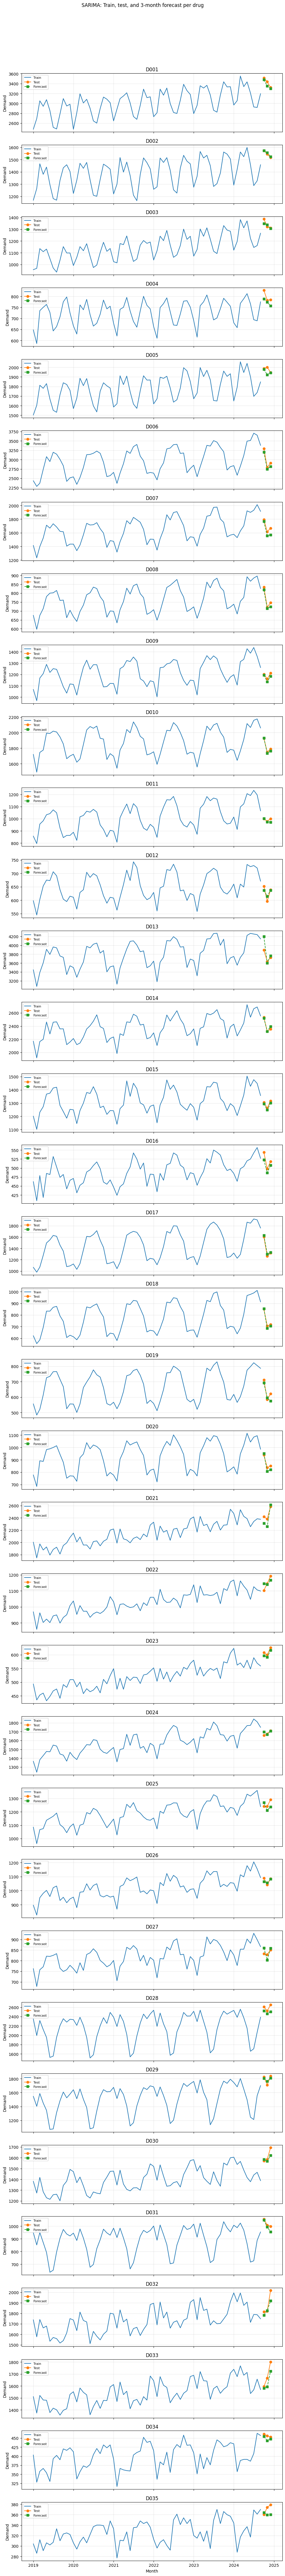

In [5]:
n_drugs = len(drug_ids)
fig, axes = plt.subplots(n_drugs, 1, figsize=(10, 2.5 * n_drugs), sharex=True)
if n_drugs == 1:
    axes = [axes]
for ax, drug_id in zip(axes, drug_ids):
    train = train_data[drug_id]
    test = test_data[drug_id]
    fc = forecasts[drug_id]
    ax.plot(train.index, train.values, label="Train", color="C0")
    ax.plot(test.index, test.values, label="Test", color="C1", marker="o")
    ax.plot(fc.index, fc.values, label="Forecast", color="C2", linestyle="--", marker="s")
    ax.set_ylabel("Demand")
    ax.set_title(f"{drug_id}")
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Month")
plt.suptitle("SARIMA: Train, test, and 3-month forecast per drug", y=1.02)
plt.tight_layout()
plt.show()

## 6. Residual Diagnostics

For each model: residual plot, ACF of residuals, Ljung–Box test (to check for remaining autocorrelation).

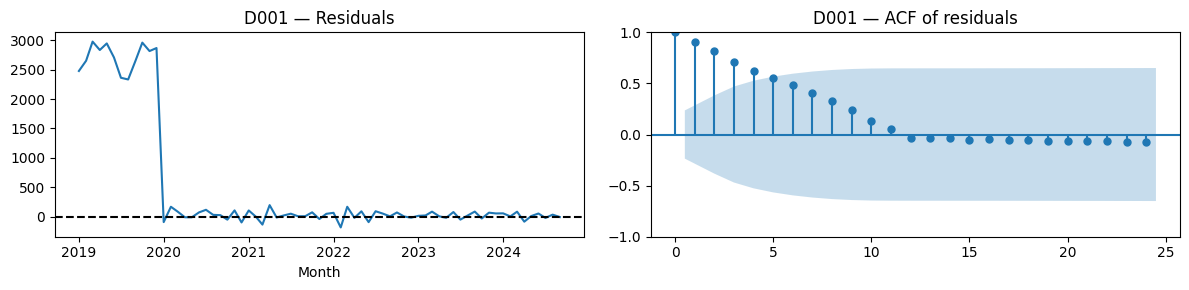

Ljung-Box (lag=12) p-value: 0.0000



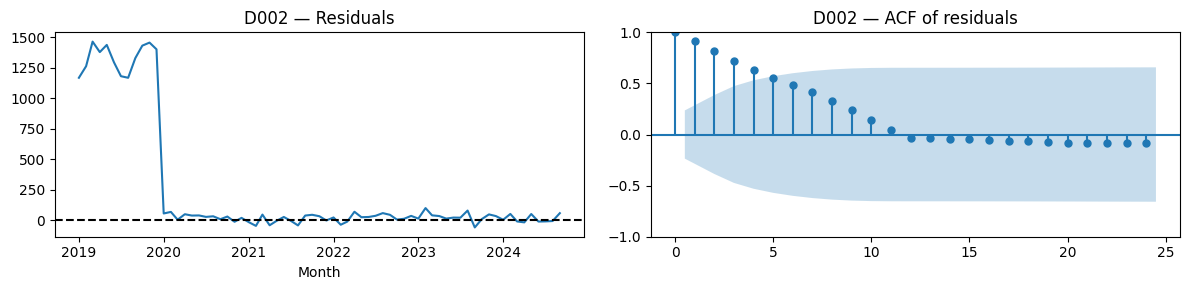

Ljung-Box (lag=12) p-value: 0.0000



In [6]:
from statsmodels.graphics.tsaplots import plot_acf

# Residuals and Ljung-Box for first 2 drugs (example)
for drug_id in drug_ids[:2]:
    res = fitted_models[drug_id].resid
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    axes[0].plot(res.index, res.values)
    axes[0].axhline(0, color="k", linestyle="--")
    axes[0].set_title(f"{drug_id} — Residuals")
    axes[0].set_xlabel("Month")
    plot_acf(res.dropna(), lags=min(24, len(res) // 2 - 1), ax=axes[1])
    axes[1].set_title(f"{drug_id} — ACF of residuals")
    plt.tight_layout()
    plt.show()
    lb = acorr_ljungbox(res.dropna(), lags=[12], return_df=True)
    print(f"Ljung-Box (lag=12) p-value: {lb['lb_pvalue'].values[0]:.4f}\n")

In [7]:
# Ljung-Box p-values for all drugs (p > 0.05 suggests residuals are white noise)
lb_results = []
for drug_id in drug_ids:
    res = fitted_models[drug_id].resid.dropna()
    lb = acorr_ljungbox(res, lags=[12], return_df=True)
    lb_results.append({"drug_id": drug_id, "ljungbox_pvalue": lb["lb_pvalue"].values[0]})
pd.DataFrame(lb_results)

,drug_id,ljungbox_pvalue
0,D001,2.156092e-45
1,D002,2.101046e-46
2,D003,2.515731e-46
3,D004,1.030281e-46
4,D005,3.562231e-47
5,D006,7.145630e-48
6,D007,8.420851e-48
7,D008,9.160309e-48
8,D009,1.804615e-48
9,D010,4.252838e-48


## 7. Save Evaluation Metrics

In [8]:
metrics_df.to_csv(OUTPUTS_DIR / "evaluation_metrics.csv", index=False)
print("Saved: outputs/evaluation_metrics.csv")
metrics_df

Saved: outputs/evaluation_metrics.csv


,drug_id,MAE,RMSE,MAPE
0,D001,47.156236,54.809518,1.371342
1,D002,7.125450,8.378715,0.463645
2,D003,20.468741,25.357204,1.501837
3,D004,25.005208,27.999672,3.103830
4,D005,30.149890,45.708553,1.508396
5,D006,77.713299,81.098476,2.565828
6,D007,61.355356,67.500609,3.676765
7,D008,14.629160,15.912309,1.901104
8,D009,20.065172,21.753617,1.687427
9,D010,13.502081,16.463282,0.757451
